In [ ]:
KGAT_e44525f2794761d27998b1cbede2b30d

In [2]:
# Install library
!pip install opendatasets

import opendatasets as od

#Download dataset
dataset_url = "https://www.kaggle.com/datasets/quynhlecl/lung-cancer-x-ray"
od.download(dataset_url)

# List downloaded files
import os
os.listdir()

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: reenasaxena
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/quynhlecl/lung-cancer-x-ray


100%|██████████| 2.28G/2.28G [00:37<00:00, 66.0MB/s]


['.config', 'lung-cancer-x-ray', 'sample_data']

In [4]:
import os

os.environ['KAGGLE_USERNAME'] = "reenasaxena"
os.environ['KAGGLE_KEY'] = "KGAT_e44525f2794761d27998b1cbede2b30d"

In [7]:
!pip install kagglehub

In [8]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("quynhlecl/lung-cancer-x-ray")

print("Path to dataset files:", path)

100%|██████████| 2.28G/2.28G [00:10<00:00, 229MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/quynhlecl/lung-cancer-x-ray/versions/1


In [9]:
import os
os.listdir(path)

['chest_xray_lung']

(np.float64(-0.5), np.float64(1079.5), np.float64(631.5), np.float64(-0.5))

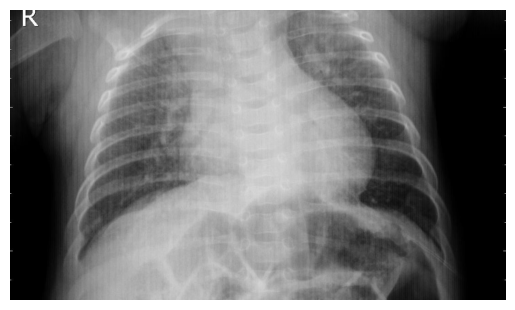

In [11]:
import cv2
import matplotlib.pyplot as plt
import os

sample_folder = os.listdir(path)[0]
sample_path = os.path.join(path, sample_folder)

# The previous line `img_file = os.listdir(sample_path)[0]`
# incorrectly picked a directory ('train') instead of an image file.
# We need to navigate deeper into the directory structure to find an actual image.

# Go into the 'train' subdirectory
train_path = os.path.join(sample_path, 'train')

# Get the list of classes/categories inside 'train' (e.g., 'NORMAL', 'PNEUMONIA')
classes = os.listdir(train_path)

# Pick the first class (e.g., 'NORMAL')
first_class_path = os.path.join(train_path, classes[0])

# Get the list of image files inside the chosen class
image_files_in_class = os.listdir(first_class_path)

# Pick the first image file
img_file_name = image_files_in_class[0]
full_image_path = os.path.join(first_class_path, img_file_name)

img = cv2.imread(full_image_path) # Now 'img' should be a valid image array

plt.imshow(img)
plt.axis("off")

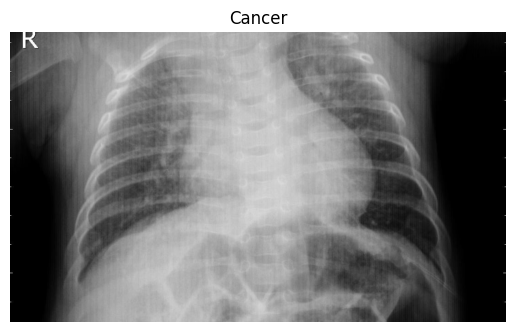

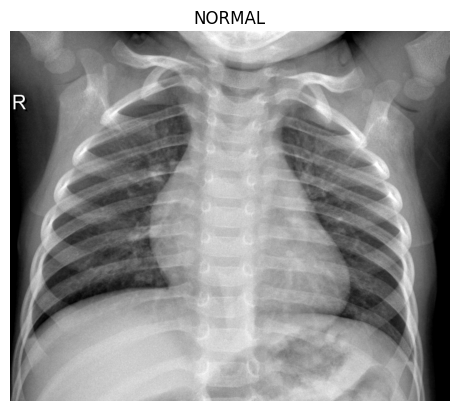

In [13]:
import os
import matplotlib.pyplot as plt
import cv2

# `path` is already defined from previous cells.

# The `classes` variable from the original code was misleading.
# It was `['chest_xray_lung']`, which is a single directory containing train/test/val.
# The user likely intended to iterate through image classes like 'NORMAL', 'CANCER', etc.
# Let's adjust the loop to correctly iterate through subdirectories within 'train'
# that represent image classes, and display one image from each.

# Assume the structure is path/main_data_folder/train/CLASS/image.jpg
main_data_folder = os.listdir(path)[0] # e.g., 'chest_xray_lung'
main_data_path = os.path.join(path, main_data_folder) # e.g., '/.../chest_xray_lung'

train_dir = os.path.join(main_data_path, 'train')

# Now, 'image_categories' should refer to the actual image categories within 'train'
image_categories = os.listdir(train_dir)

for category in image_categories:
    category_path = os.path.join(train_dir, category)
    # Ensure it's a directory and not empty
    if os.path.isdir(category_path) and len(os.listdir(category_path)) > 0:
        # Get the first image file in this category
        img_file_name = os.listdir(category_path)[0]
        full_image_path = os.path.join(category_path, img_file_name)

        img = cv2.imread(full_image_path)

        if img is not None:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(category) # Use category as title
            plt.axis("off")
            plt.show()
        else:
            print(f"Warning: Could not read image at {full_image_path}")
    else:
        print(f"Warning: Category path {category_path} is not a valid directory or is empty.")

In [14]:
IMG_SIZE = 224

img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img / 255.0

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [16]:
dataset_path = path

In [17]:
os.listdir(dataset_path)

['chest_xray_lung']

In [18]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 9370 images belonging to 1 classes.
Found 2342 images belonging to 1 classes.


In [19]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 830s 3s/step - accuracy: 0.9794 - loss: 0.0163 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 807s 3s/step - accuracy: 1.0000 - loss: 7.4428e-35 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 832s 3s/step - accuracy: 1.0000 - loss: 1.2591e-30 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 819s 3s/step - accuracy: 1.0000 - loss: 4.1166e-39 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 912s 3s/step - accuracy: 1.0000 - loss: 1.3288e-36 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 818s 3s/step - accuracy: 1.0000 - loss: 2.6523e-32 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 803s 3s/step - accuracy: 1.0000 - loss: 1.9370e-35 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 826s 

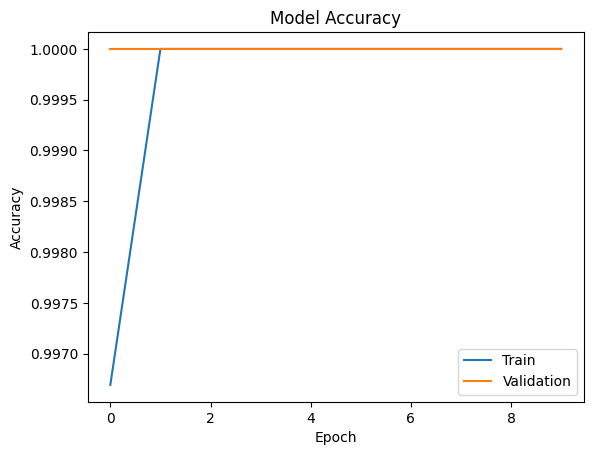

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [24]:
model.save("lung_cancer_cnn_model.keras")

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [26]:
val_generator.reset()

predictions = model.predict(val_generator)

predicted_classes = (predictions > 0.5).astype(int)
true_classes = val_generator.classes

74/74 ━━━━━━━━━━━━━━━━━━━━ 71s 930ms/step


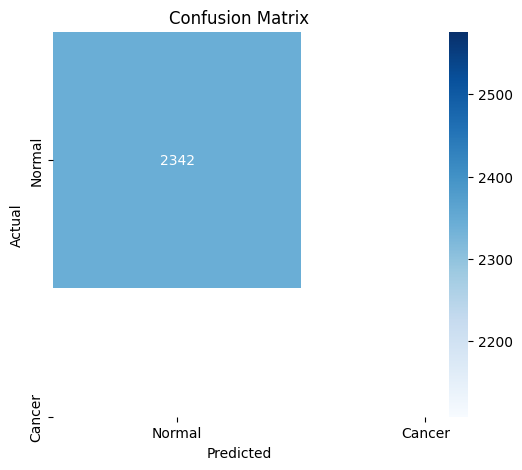

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Normal","Cancer"],
            yticklabels=["Normal","Cancer"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

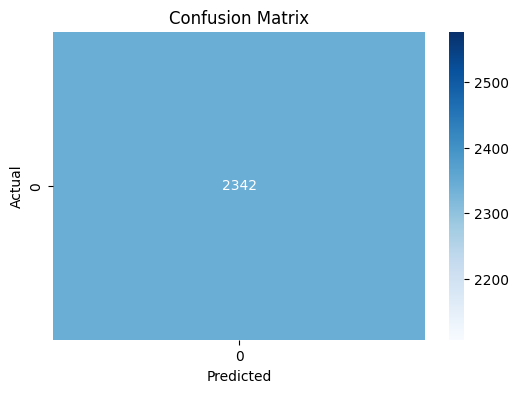

In [29]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2342

    accuracy                           1.00      2342
   macro avg       1.00      1.00      1.00      2342
weighted avg       1.00      1.00      1.00      2342



In [32]:
import cv2
import numpy as np
import os # Import os module if not already imported

# Assuming 'full_image_path' is defined from previous exploration cells (e.g., kScfDvqk_v3s or rXPSAHz5AMuV)
# If not, you might need to re-run an earlier cell or define it here.
# For example, let's redefine it based on the current notebook state (if it got reset or was not directly available).

# Let's ensure full_image_path is available, replicating how it was derived in earlier cells
if 'path' in locals() and os.path.exists(path):
    main_data_folder = os.listdir(path)[0] # e.g., 'chest_xray_lung'
    main_data_path = os.path.join(path, main_data_folder)
    train_dir = os.path.join(main_data_path, 'train')
    image_categories = os.listdir(train_dir)
    if 'NORMAL' in image_categories:
        first_class_path = os.path.join(train_dir, 'NORMAL') # Use 'NORMAL' for a clear test case
        image_files_in_class = os.listdir(first_class_path)
        if len(image_files_in_class) > 0:
            img_file_name = image_files_in_class[0]
            test_image_path = os.path.join(first_class_path, img_file_name)
        else:
            test_image_path = None # Handle case where folder is empty
    else:
        test_image_path = None # Handle case where 'NORMAL' category is missing
else:
    test_image_path = None # Handle case where 'path' is not defined or invalid

if test_image_path and os.path.exists(test_image_path):
    img = cv2.imread(test_image_path)
    if img is not None:
        img = cv2.resize(img, (224,224))
        img = img / 255.0

        img = np.expand_dims(img, axis=0)

        prediction = model.predict(img)

        if prediction > 0.5:
            print("Cancer Detected")
        else:
            print("Normal Lung")
    else:
        print(f"Error: Could not read image from {test_image_path}. Check file corruption.")
else:
    print("Error: Test image file not found or path not correctly defined. Please ensure the dataset is downloaded and accessible.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
Normal Lung


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


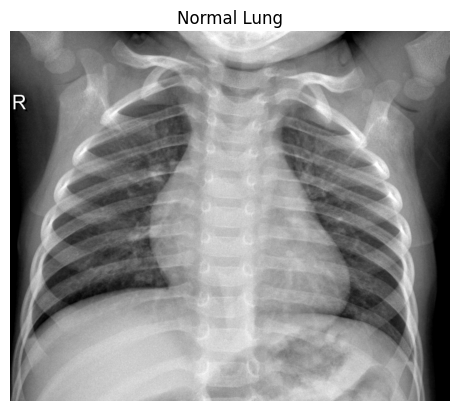

In [34]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Use the test_image_path that was correctly defined in the previous cell
# This path points to an actual image in the downloaded dataset.
# If `test_image_path` is not globally available or might be overwritten,
# you might need to re-run the previous cell or explicitly define it here.

# For robustness, let's ensure test_image_path is available, similar to the previous cell.
# This ensures the code can run independently if necessary.
import os
if 'path' in locals() and os.path.exists(path):
    main_data_folder = os.listdir(path)[0]
    main_data_path = os.path.join(path, main_data_folder)
    train_dir = os.path.join(main_data_path, 'train')
    image_categories = os.listdir(train_dir)
    if 'NORMAL' in image_categories:
        first_class_path = os.path.join(train_dir, 'NORMAL')
        image_files_in_class = os.listdir(first_class_path)
        if len(image_files_in_class) > 0:
            img_path = os.path.join(first_class_path, image_files_in_class[0])
        else:
            img_path = None
    else:
        img_path = None
else:
    img_path = None

if img_path and os.path.exists(img_path):
    img = cv2.imread(img_path)
    if img is not None:
        img_resized = cv2.resize(img,(224,224))
        img_norm = img_resized / 255.0
        img_input = np.expand_dims(img_norm, axis=0)

        prediction = model.predict(img_input)

        label = "Cancer Detected" if prediction > 0.5 else "Normal Lung"

        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(label)
        plt.axis("off")
        plt.show()
    else:
        print(f"Error: Could not read image from {img_path}. Check file corruption.")
else:
    print("Error: Image file not found or path not correctly defined. Please ensure the dataset is downloaded and accessible.")

In [35]:
model.save("lung_cancer_model.keras")

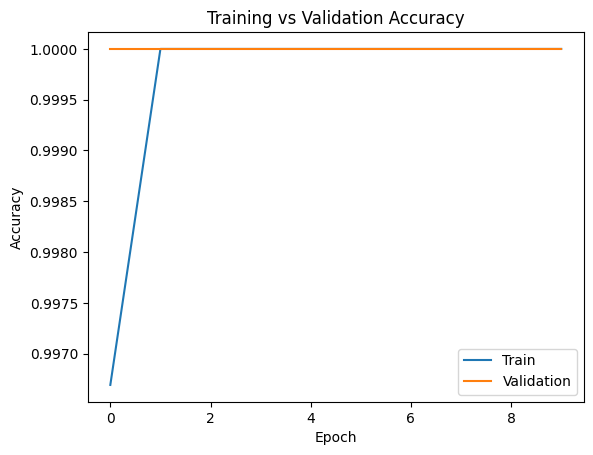

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()